# Seminar 3 - Wi-Fi fingerprinting with K-Means

#### Corentin LE BRIS (335776)  
#### Antoine METZ (335801)

In this seminar, the goal is to locate a user from RSSI measurements collected by three access points. We first look at the data to see how the positions are separated, then we implement a simple K-Means algorithm by hand and compare the clusters with the real positions.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

## 1. Data loading and visualisation

The dataset has two files. The first one contains the RSSI values measured by AP1, AP2 and AP3. The second one contains the real position of the station for each measurement. Since both files are aligned row by row, we can concatenate them and keep the position as the label used only for analysis and evaluation.

In [20]:
rssi_df = pd.read_csv('rssi_data.csv', header=None, names=['AP1', 'AP2', 'AP3'])
labels_df = pd.read_csv('labels_data.csv', header=None, names=['Position'])

# Merge the RSSI measurements and the real position in the same dataframe.
df = pd.concat([rssi_df, labels_df], axis=1)

df.head()

The 2-D plots compare the RSSI values two access points at a time. This is useful because if the positions already appear separated in these views, then clustering should be possible with a simple distance-based method.

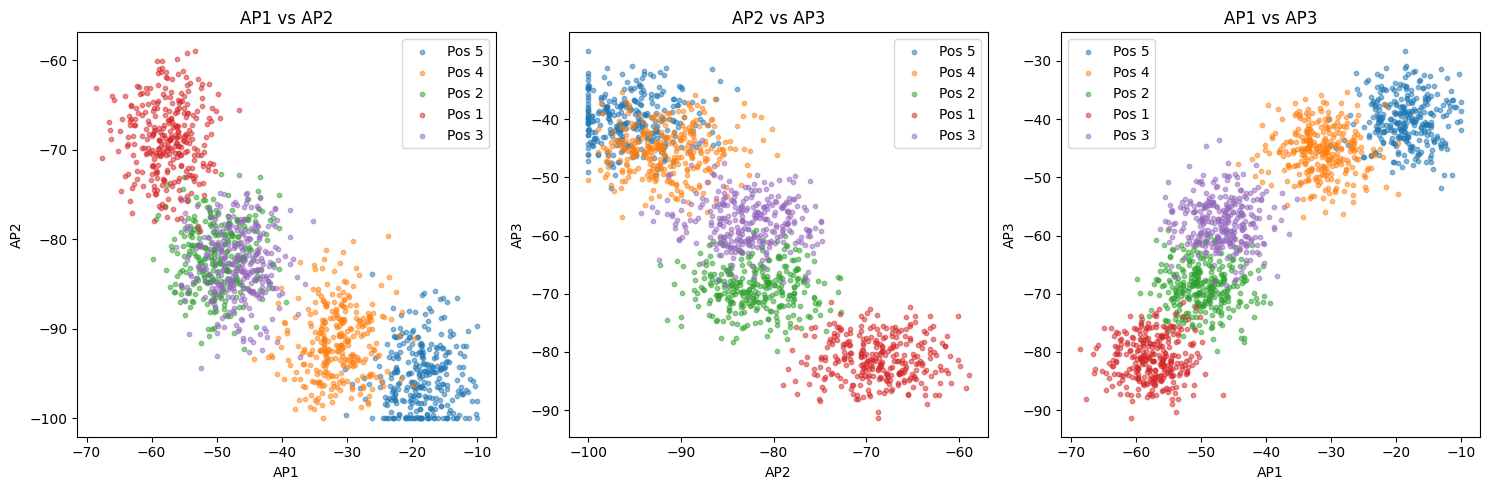

In [21]:
# 2D plot of RSSI for each combination of APs
plt.figure(figsize=(15, 5))

pairs = [('AP1', 'AP2'), ('AP2', 'AP3'), ('AP1', 'AP3')]

for i, (x, y) in enumerate(pairs, 1):
    plt.subplot(1, 3, i)
    for pos in df['Position'].unique():
        subset = df[df['Position'] == pos]
        plt.scatter(subset[x], subset[y], label=f'Pos {pos}', s=10, alpha=0.5)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f'{x} vs {y}')
    plt.legend()

plt.tight_layout()
plt.show()

The same idea is shown in 3-D with the three APs at the same time. In this space, each point is one RSSI measurement described by AP1, AP2 and AP3.

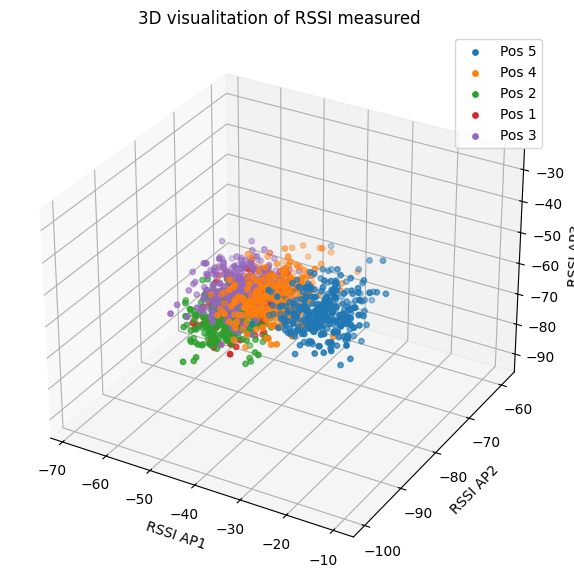

In [22]:
# 3D plot using the RSSI of the three APs
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for pos in df['Position'].unique():
    subset = df[df['Position'] == pos]
    ax.scatter(subset['AP1'], subset['AP2'], subset['AP3'], label=f'Pos {pos}', s=15)

ax.set_xlabel('RSSI AP1')
ax.set_ylabel('RSSI AP2')
ax.set_zlabel('RSSI AP3')
ax.set_title('3D visualisation of RSSI measurements')
plt.legend()
plt.show()

We also compute the mean and standard deviation of the RSSI at each position. The mean gives the typical RSSI fingerprint of the position, while the standard deviation gives an idea of the variability around this fingerprint.

In [23]:
# Statistics by real position
stats = df.groupby('Position').agg(['mean', 'std'])
print("Statistics for each position:")
print(stats)

statistics for each position :
                AP1                  AP2                  AP3          
               mean       std       mean       std       mean       std
Position                                                               
1        -57.547793  3.676167 -68.772187  4.041594 -81.156930  3.748209
2        -49.811667  3.892066 -81.979633  3.760133 -68.978473  3.869161
3        -46.740827  3.951756 -82.877667  3.981708 -57.633320  4.141495
4        -31.584760  4.058027 -91.492630  3.944587 -45.475647  4.102736
5        -18.477953  3.860880 -95.344790  3.531129 -40.081403  4.128701


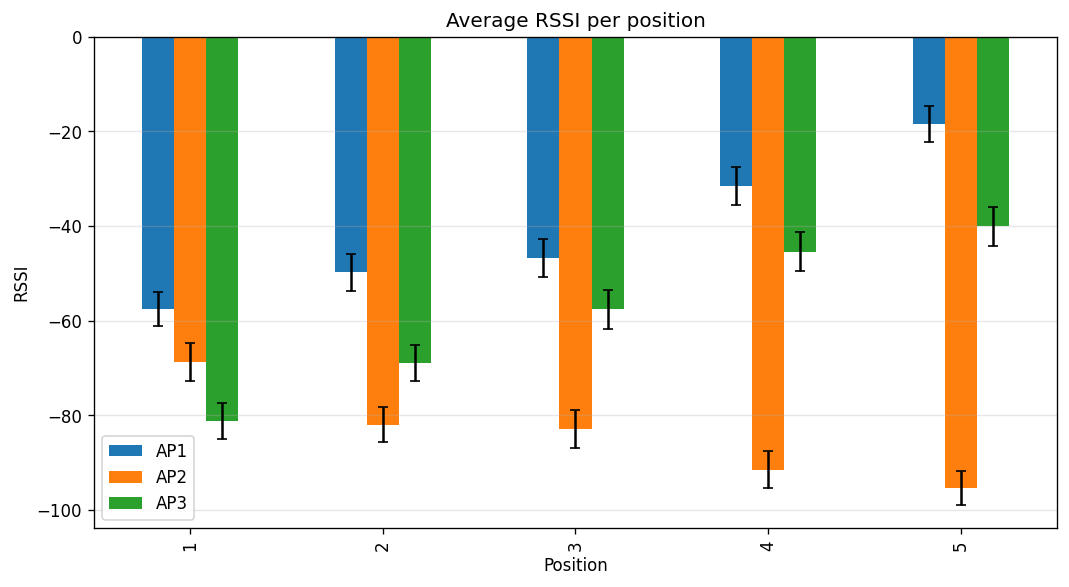

In [24]:
# Plot the mean RSSI for each AP, with the standard deviation as error bars
mean_stats = df.groupby('Position')[['AP1', 'AP2', 'AP3']].mean()
std_stats = df.groupby('Position')[['AP1', 'AP2', 'AP3']].std()

ax = mean_stats.plot(kind='bar', yerr=std_stats, capsize=3, figsize=(9, 5))
ax.set_title('Average RSSI per position')
ax.set_xlabel('Position')
ax.set_ylabel('RSSI')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

The averages are not the same for the five positions. For example, AP1 becomes much stronger from position 1 to position 5, while AP2 becomes weaker. This confirms that the RSSI vector can act as a fingerprint for the location.

## 2. K-Means implementation

For the second part, we implement K-Means ourselves instead of directly using a library function. The algorithm starts with random centroids, assigns every point to the closest centroid using Euclidean distance, then updates the centroids with the mean of the assigned points. We stop when assignments no longer change or when the maximum number of iterations is reached.

In [24]:
def kmeans(data, k=5, max_iterations=100):
    # Random initialization of the centroids in the RSSI space.
    n_samples, n_features = data.shape
    random_indices = np.random.choice(n_samples, k, replace=False)
    centroids = data[random_indices]

    labels = np.zeros(n_samples)

    for t in range(max_iterations):
        old_labels = labels.copy()

        # Assign each point to the nearest centroid.
        for i in range(n_samples):
            distances = np.linalg.norm(data[i] - centroids, axis=1)
            labels[i] = np.argmin(distances)

        # Update each centroid with the mean of its cluster.
        for j in range(k):
            points_in_cluster = data[labels == j]

            if len(points_in_cluster) > 0:
                centroids[j] = points_in_cluster.mean(axis=0)
            else:
                # If a cluster is empty, we reinitialize it with a random point.
                centroids[j] = data[np.random.choice(n_samples)]

        # Convergence condition: assignments do not change anymore.
        if np.array_equal(labels, old_labels):
            print(f"Convergence reached at iteration {t}")
            break

    return centroids, labels

# Data used by K-Means: AP1, AP2 and AP3 RSSI values.
data_points = rssi_df.values

final_centroids, predicted_labels = kmeans(data_points, k=5)

Convergence reached at iteration 8


The cluster numbers returned by K-Means are arbitrary. Cluster 0 does not necessarily mean position 1. Because of that, we first map each cluster to the real position that appears the most inside it, then we compute the accuracy.

In [25]:
# update labels indexes for comparison with ground truth data
predicted_labels_adjusted = predicted_labels + 1

# create a comparison table
comparison_df = pd.DataFrame({
    'Real_Position': labels_df['Position'].values,
    'KMeans_Cluster': predicted_labels_adjusted
})

print(comparison_df.head(10))

   Real_Position  KMeans_Cluster
0              5             4.0
1              4             5.0
2              5             4.0
3              2             3.0
4              2             3.0
5              2             3.0
6              2             3.0
7              1             2.0
8              4             5.0
9              2             3.0


In [26]:
labels_pred_final = np.zeros_like(predicted_labels)

for i in range(5):
    # Real positions of the samples assigned to cluster i.
    true_position = labels_df['Position'][predicted_labels == i]

    # We associate the cluster with the most frequent real position in it.
    result = true_position.mode()

    if not result.empty:
        likely_pos = result.iloc[0]
        labels_pred_final[predicted_labels == i] = likely_pos

check_df = pd.DataFrame({
    'Real position': labels_df['Position'],
    'Prediction_Adjusted': labels_pred_final
})

accuracy = (check_df['Real position'] == check_df['Prediction_Adjusted']).mean()
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 95.87%


The result is high, which means that the five RSSI fingerprints are quite well separated in this synthetic dataset. Some errors can still happen because the RSSI values have variability, so a few measurements can fall closer to the wrong centroid.

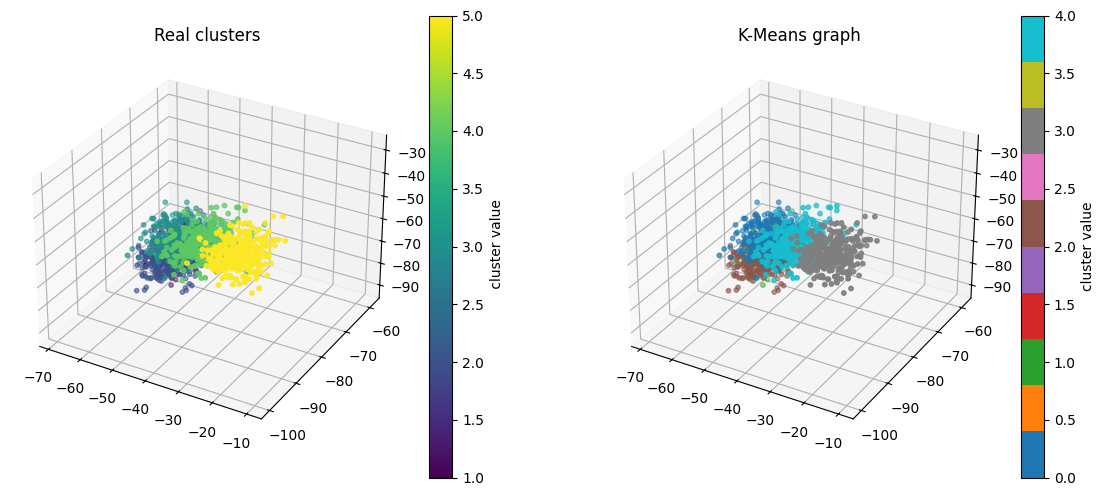

In [28]:
fig = plt.figure(figsize=(14, 6))

# Left: real positions from the dataset.
ax1 = fig.add_subplot(121, projection='3d')
scatter1 = ax1.scatter(
    data_points[:, 0], data_points[:, 1], data_points[:, 2],
    c=labels_df['Position'], cmap='viridis', s=10
)
ax1.set_title('Real positions')
ax1.set_xlabel('RSSI AP1')
ax1.set_ylabel('RSSI AP2')
ax1.set_zlabel('RSSI AP3')
plt.colorbar(scatter1, ax=ax1, label='Position')

# Right: clusters found by K-Means.
ax2 = fig.add_subplot(122, projection='3d')
scatter2 = ax2.scatter(
    data_points[:, 0], data_points[:, 1], data_points[:, 2],
    c=predicted_labels, cmap='tab10', s=10
)
ax2.scatter(
    final_centroids[:, 0], final_centroids[:, 1], final_centroids[:, 2],
    c='red', marker='x', s=100, label='Centroids'
)
ax2.set_title('K-Means clusters')
ax2.set_xlabel('RSSI AP1')
ax2.set_ylabel('RSSI AP2')
ax2.set_zlabel('RSSI AP3')
plt.colorbar(scatter2, ax=ax2, label='Cluster')

plt.show()

## Conclusion

This notebook follows the Wi-Fi fingerprinting workflow of the seminar. We first checked the RSSI measurements with 2-D and 3-D plots, then computed the mean and standard deviation for each position. After that, we implemented K-Means by hand and used it to cluster the RSSI fingerprints.

After matching each cluster to the closest real position label, the model reaches about 95.9% accuracy. This makes sense because the synthetic positions form fairly clear groups in the RSSI space, even if the measurements are not perfectly separated.